In [6]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticke

from matrix_processing_helpers import sparsify_global_percentile
from plot_helpers import plot_rollout_graph, plot_feature_ranking_comparison

### Load data

In [2]:
with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [3]:
feature_names_short = ['1,5-Anhydrosorbitol', '2-Aminobutyric \n acid', '2-Hydroxybutyric \n acid', 
                       '2-Oxoglutaric \n acid', '3-Hydroxyisobutyric \n acid', 'Acetic \n acid', 
                       'Acetoacetic \n acid', 'Acetone', 'Alanine', 'Albumin', 
                       'Apolipoprotein B', 'Arginine', 'Asparagine', 'Aspartate', 
                       'BCAA to AAA \n ratio', 'Betaine', 'Bilirubin', 'C reactive \n protein', 
                       'Calcium', 'Choline', 'Citric \n acid', 'Creatine', 'Creatinine', 
                       'Cystine', 'D-Galactose', 'Dimethylamine', 'Dimethylsulfone', 
                       'Erythrocyte \n sedimentation \n rate', 'Erythrocytes', 
                       'Estimated \n Glomerular \n Filtration \n Rate', 'Ethanol', 'Formic acid', 
                       'Glucose', 'Glutamic \n acid', 'Glutamine', 
                       'Glutamine to \n glutamate ratio', 'Glyc A', 'GlycB to \n GlycA ratio', 
                       'Glycerol', 'Glycine', 'HDL cholesterol', 'Histidine', 'Iron', 
                       'LDL cholesterol', 'Lactate to \n pyruvate ratio', 'Lactic acid', 
                       'Leucine', 'Leukocytes', 'Lipoprotein(a)', 'Lysine', 
                       'Methanol', 'Methionine', 'Myo-inositol', 'N,N-Dimethylglycine', 
                       'Non-albumin \n protein', 'Ornithine', 'Phenylalanine', 'Platelets', 
                       'Proline', 'Pyruvic \n acid', 'SPC', 'Sarcosine', 'Serine', 
                       'Succinic \n acid', 'Threonine', 'Transferrin', 'Triglycerides', 
                       'Trimethylamine-N-oxide', 'Tyrosine', 'Urate', 'Urea', 
                       'Urea to creatinine \n ratio']

In [4]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

In [ ]:
LAYER = 11

plt.rcParams["font.family"] = "serif"

cmap_attn = LinearSegmentedColormap.from_list("black_green", ["black", "#00FF00"])

results_rollout = np.load(ROLL_GLOB / f"{LAYER}layers/rollout{LAYER}layers.npz")

R = results_rollout["rollout"]

d = R.shape[0]
v = (R.T @ np.ones(d)) / d
Pi_R = np.outer(np.ones(d), v)

difference = R - Pi_R

vmin_main = min(R.min(), Pi_R.min())
vmax_main = max(R.max(), Pi_R.max())

# Symmetric scale for the residual
diff_max = np.max(np.abs(difference))
diff_norm = TwoSlopeNorm(vmin=-diff_max, vcenter=0.0, vmax=diff_max)

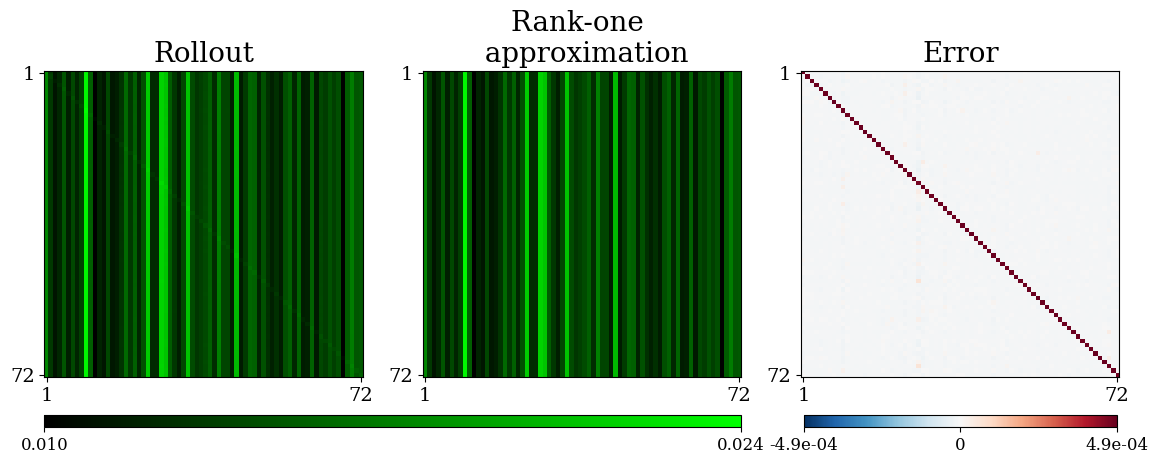

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 5))

# R
im_R = axes[0].imshow(R, aspect="auto", cmap=cmap_attn, vmin=vmin_main, vmax=vmax_main)
axes[0].set_title("Rollout", fontsize=20)

# Pi_R
im_Pi = axes[1].imshow(Pi_R, aspect="auto", cmap=cmap_attn, vmin=vmin_main, vmax=vmax_main)
axes[1].set_title("Rank-one \n approximation", fontsize=20)

# R - Pi_R
im_diff = axes[2].imshow(difference, aspect="auto", cmap="RdBu_r", norm=diff_norm)
axes[2].set_title("Error", fontsize=20)

# Axis formatting
for ax in axes:
    ax.set_xticks(ticks=[0, d - 1], labels=[1, d], fontsize=14)
    ax.set_yticks(ticks=[0, d - 1], labels=[1, d], fontsize=14)

plt.tight_layout(rect=[0, 0.15, 1, 1])

pos0 = axes[0].get_position()
pos1 = axes[1].get_position()
pos2 = axes[2].get_position()

cb_height = 0.025
cb_gap = 0.1

left1 = pos0.x0
right1 = pos1.x1

cax1 = fig.add_axes([left1, pos0.y0 - cb_gap, right1 - left1, cb_height])

cbar1 = fig.colorbar(im_R, cax=cax1, orientation="horizontal")

cbar1.set_ticks([vmin_main, vmax_main])
cbar1.set_ticklabels([f"{vmin_main:.3f}", f"{vmax_main:.3f}"])
cbar1.ax.tick_params(labelsize=12)

center = 0.5 * (pos2.x0 + pos2.x1)
width = 0.45*(right1 - left1)      # same width as first colorbar

cax2 = fig.add_axes([center - width/2, pos2.y0 - cb_gap, width, cb_height])

cbar2 = fig.colorbar(im_diff, cax=cax2, orientation="horizontal")

cbar2.set_ticks([-diff_max, 0, diff_max])
cbar2.set_ticklabels([f"{-diff_max:.1e}", "0", f"{diff_max:.1e}"])
cbar2.ax.tick_params(labelsize=12)


plt.savefig(FIG_DIR / f"rollout_rank_one.pdf", bbox_inches="tight")

plt.show()

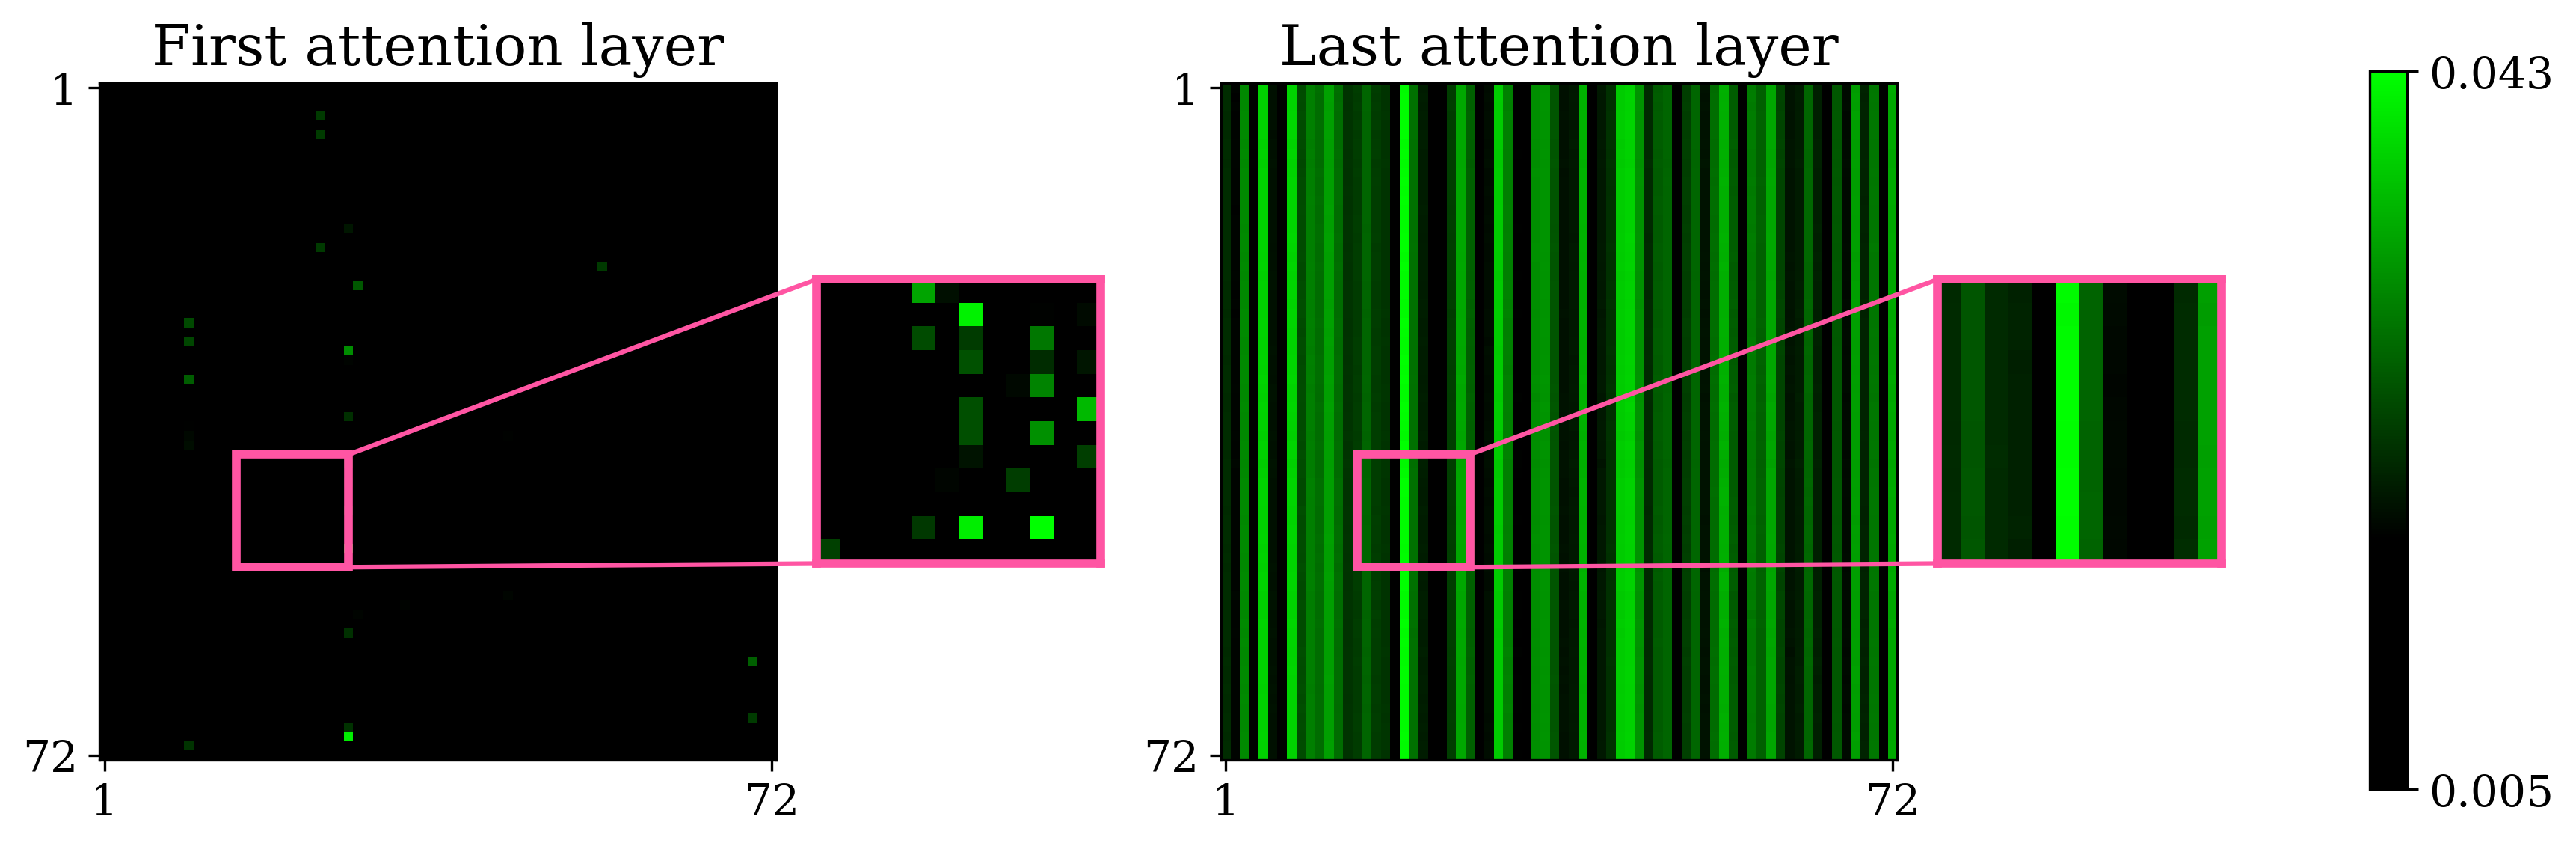

In [9]:
N_LAYERS = 11
with open(f"Results/rollout_local/{N_LAYERS}layers/attn_matrices{N_LAYERS}layers.pkl", "rb") as f:
    attn_matrices = pickle.load(f)

attn_list = [np.mean(attn_matrices[key]['attn_matrix'], axis=0) for key in attn_matrices.keys()]

matrices = [attn_list[0], attn_list[-1]]

titles = ["First attention layer", "Last attention layer"]
centers = 4*[(45, 20)]
sizes = 4*[12]

# Shared normalization across all matrices
all_values = np.concatenate([M.ravel() for M in matrices])
vmin = np.percentile(all_values, 2)
vmax = np.percentile(all_values, 99)

fig, axes = plt.subplots(1, 2, figsize=(11, 8), dpi=300)

axes = axes.ravel()

cmap_attn = LinearSegmentedColormap.from_list("black_green",
                                              [(0.0, "black"), (0.35, "black"), (1.0, "#00FF00")])

for ax, M, title, center, size in zip(axes, matrices, titles, centers, sizes):
    im, axins = draw_matrix_with_external_zoom(fig=fig, ax=ax, M=M, title=title, 
                                               center=center, size=size, cmap=cmap_attn,
                                               patch_color="#FF55A3",
                                               # vmin=vmin, vmax=vmax
                                              )

plt.subplots_adjust(left=0.04, right=0.90, bottom=0.05, top=0.92, wspace=0.12, hspace=0.10)

limits = im.get_clim()
# after creating all plots
cax = fig.add_axes([0.96, 0.28, 0.015, 0.4])  # [left, bottom, width, height]

cbar = fig.colorbar(im, cax=cax)
cbar.set_ticks(limits)
cbar.set_ticklabels([f"{vmin:.3f}", f"{vmax:.3f}"])
cbar.ax.tick_params(labelsize=14)
# cbar.set_label("Value", fontsize=16)

# plt.savefig(FIG_DIR / "attn_matrices_zoom.pdf", bbox_inches="tight")

plt.show()